<a href="https://colab.research.google.com/github/j-c-stuifbergen/AP3531-homework-1/blob/main/AP3531_Assignment_1A_J_C_Stuifbergen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home work 1A

## Import packages

In [1]:
# Import packages that are required
import numpy as np
import matplotlib.pyplot as plt
import math

f =19.53125 Hz
lambda =100.0 m


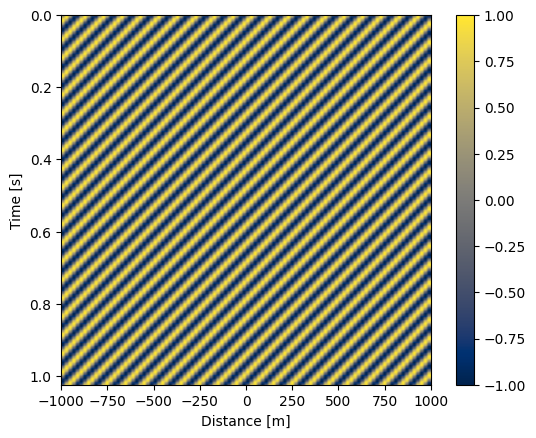

In [2]:
# @title #Define a plane wave

# x=−1000m to x=+990 m with a spatial sampling of 20 m (i.e. 100 signals
# in the x-direction) and 256 samples in the time direction with t=4ms.
# create the x-axis, assuming dx=20m and center is x=0
xmin=-1000
xmax = 990
dx=20
nx=math.ceil((xmax-xmin)/dx)
nx=100
xmax = xmin+nx*dx
xaxis=xmin+np.arange(nx)*dx
tmin = 0
nt = 256
dt = 0.004
taxis = tmin+np.arange(nt)*dt
tmax = tmin+nt*dt
# fictitious omega , relative to the number of samples
omega =20* 2*np.pi / nt
f = omega/ (2*np.pi)*nt/(tmax-tmin)
print( 'f ='+str(f)+' Hz')
k0 = 20 * 2 * np.pi/nx
lambda0 = (xmax-xmin)*(2*np.pi)/k0/nx
print( 'lambda =' +str(lambda0) + ' m')
alph0 =0 # I could add a phase shift
data=np.zeros((nx,nt))
for ix in range(nx):
    for it in range(nt):
        data[ix,it]=np.sin(alph0+k0*ix + omega*it)

# Plotting the 2D array as grey-level image; plot transpose to get the time-axis downward
# the aspect value is to make sure the plot is a rectanlge (try without).
plt.figure()
plt.imshow(data.T,cmap='cividis',extent=[xmin,xmax,tmax, tmin], aspect = (-xmin+xmax)/(tmax-tmin))
plt.xlabel("Distance [m]")
plt.ylabel("Time [s]")
plt.colorbar()
plt.show()

(100, 256)
(100, 129)


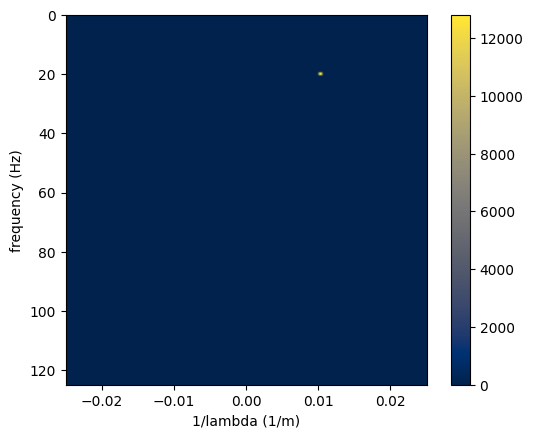

In [3]:
# @title Fourier transform of a plane wave
# Example to make the FK plot of the 2D array
# Note the following:
# - we use rfft2 to do first a real-complex over time and regular FFT over x
# - we plot again the transposed to make frequency axis downward
# - we apply fftshft with axes=1 to put kx=0 in the middle
# - we flip over the kx-axis, because in our definition FFT over x has + sign in the forward transform

# Note that with this case of a horizontal event, we only expect contrbution at kx=0
print(data.shape)
FK=np.fft.rfft2(data)
print(FK.shape)
plt.figure()
plt.imshow(((np.abs(np.fft.fftshift(FK.T,axes=1))))
           ,cmap='cividis'
  ,extent=[-nx/2/(-xmin+xmax),+nx/2/(-xmin+xmax),nt/2/(-tmin+tmax),0]
          , aspect = 0.8*(-tmin+tmax)/(-xmin+xmax))
plt.xlabel("1/lambda (1/m)")
plt.ylabel("frequency (Hz)")
plt.colorbar()
plt.show()
# Note: the Fourier transform was performed on a matrix.
# scaling was added by the parameter "extent"

In [4]:
#@title ##Ricker wavelet function

def Ricker(f0,t0,t):
  mu = (np.pi**2)*(f0**2)*((t-t0)**2)
  return (1-2*mu)*np.exp(-mu)



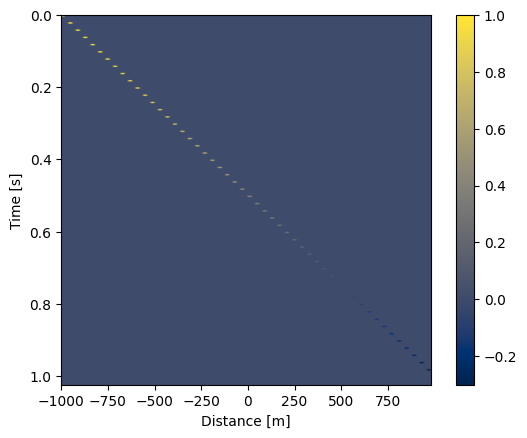

In [5]:
# @title #Define a broadband plane wave
# Peak Frequency [Hz]; note that the maximum frequency is ~2.5xf0
f0=0.3

# x=−1000m to x=+990 m with a spatial sampling of 20 m (i.e. 100 signals
# in the x-direction) and 256 samples in the time direction with t=4ms.
# create the x-axis, assuming dx=25m and center is x=0
xmin=-1000
xmax = 980
dx=20
nx=math.ceil((xmax-xmin)/dx)
#nx=100
xmax = xmin+nx*dx
xaxis=xmin+np.arange(nx)*dx
tmin = 0
nt = 256
dt = 0.004
taxis = tmin+np.arange(nt)*dt
tmax = tmin+nt*dt

speed =  2000 # m/s
v = speed /nt*tmax
# speed * dt = (tmax-tmin)/nt
# 10 = speed *
data=np.zeros((nx,nt))
for ix in range(nx):
    for it in range(nt):
        data[ix,it]=Ricker(f0, taxis[it],  (-xmin+xaxis[ix]-v*it))

# Plotting the 2D array as grey-level image; plot transpose to get the time-axis downward
# the aspect value is to make sure the plot is a rectanlge (try without).
plt.figure()
plt.imshow(data.T,cmap='cividis',extent=[xmin,xmax,tmax, tmin], aspect =(-xmin+xmax)/(tmax-tmin))
plt.xlabel("Distance [m]")
plt.ylabel("Time [s]")
plt.colorbar()
plt.show()

(99, 256)
(99, 129)


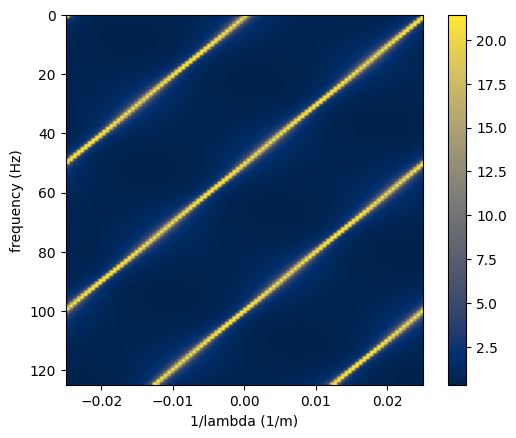

In [6]:
# @title Fourier transform of a broadband wave
# Example to make the FK plot of the 2D array
# Note the following:
# - we use rfft2 to do first a real-complex over time and regular FFT over x
# - we plot again the transposed to make frequency axis downward
# - we apply fftshft with axes=1 to put kx=0 in the middle
# - we flip over the kx-axis, because in our definition FFT over x has + sign in the forward transform

# Note that with this case of a horizontal event, we only expect contrbution at kx=0
print(data.shape)
FK=np.fft.rfft2(data)
print(FK.shape)
plt.figure()
plt.imshow(((np.abs(np.fft.fftshift(FK.T,axes=1))))
           ,cmap='cividis'
  ,extent=[-nx/2/(-xmin+xmax),+nx/2/(-xmin+xmax),nt/2/(-tmin+tmax),0]
          , aspect = 0.8*(-tmin+tmax)/(-xmin+xmax))
plt.xlabel("1/lambda (1/m)")
plt.ylabel("frequency (Hz)")
plt.colorbar()
plt.show()
# Note: the Fourier transform was performed on a matrix.
# scaling was added by the parameter "extent"

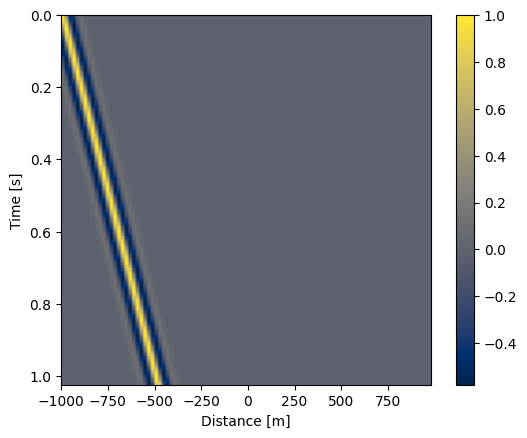

In [7]:
# @title #Define a Gabor wavelet
# Peak Frequency [Hz]; note that the maximum frequency is ~2.5xf0
f0=0.3

# x=−1000m to x=+990 m with a spatial sampling of 20 m (i.e. 100 signals
# in the x-direction) and 256 samples in the time direction with t=4ms.
# create the x-axis, assuming dx=25m and center is x=0
xmin=-1000
xmax = 980
dx=20
nx=math.ceil((xmax-xmin)/dx)
#nx=100
xmax = xmin+nx*dx
xaxis=xmin+np.arange(nx)*dx
tmin = 0
nt = 256
dt = 0.004
taxis = tmin+np.arange(nt)*dt
tmax = tmin+nt*dt

alpha = 10/ (xmax-xmin)
omega = 2*np.pi *20 / (xmax-xmin)
speed =  500 # m/s
v = speed /nt*tmax
# speed * dt = (tmax-tmin)/nt
# 10 = speed *
data=np.zeros((nx,nt))
for ix in range(nx):
    for it in range(nt):
        arg =  (-xmin+xaxis[ix]-v*it)
        data[ix,it]=np.cos(omega*arg)*np.exp(-pow(np.pi*alpha*arg,2))

# Plotting the 2D array as grey-level image; plot transpose to get the time-axis downward
# the aspect value is to make sure the plot is a rectanlge (try without).
plt.figure()
plt.imshow(data.T,cmap='cividis',extent=[xmin,xmax,tmax, tmin], aspect =(-xmin+xmax)/(tmax-tmin))
plt.xlabel("Distance [m]")
plt.ylabel("Time [s]")
plt.colorbar()
plt.show()

(99, 256)
(99, 129)


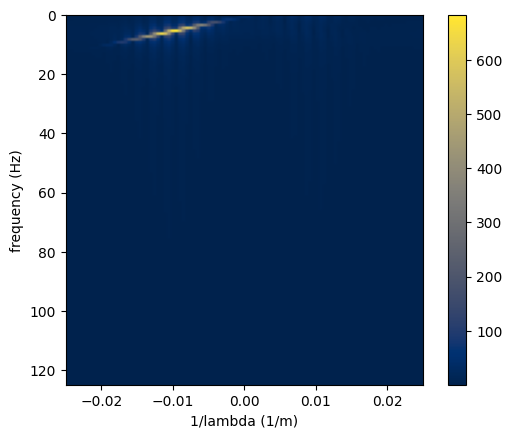

In [8]:
# @title Fourier transform of a Gabor wavelet
# Example to make the FK plot of the 2D array
# Note the following:
# - we use rfft2 to do first a real-complex over time and regular FFT over x
# - we plot again the transposed to make frequency axis downward
# - we apply fftshft with axes=1 to put kx=0 in the middle
# - we flip over the kx-axis, because in our definition FFT over x has + sign in the forward transform

# Note that with this case of a horizontal event, we only expect contrbution at kx=0
print(data.shape)
FK=np.fft.rfft2(data)
print(FK.shape)
plt.figure()
plt.imshow(((np.abs(np.fft.fftshift(FK.T,axes=1))))
           ,cmap='cividis'
  ,extent=[-nx/2/(-xmin+xmax),+nx/2/(-xmin+xmax),nt/2/(-tmin+tmax),0]
          , aspect = 0.8*(-tmin+tmax)/(-xmin+xmax))
plt.xlabel("1/lambda (1/m)")
plt.ylabel("frequency (Hz)")
plt.colorbar()
plt.show()
# Note: the Fourier transform was performed on a matrix.
# scaling was added by the parameter "extent"